# Logistic Regression

In [2]:
from IPython.display import Image

- Primarily used for **binary target variable classification.**
- Probability that a event occurs: $P(y=1) = p$. Then, $E(y) = p$. 
- $p = \beta_0 + \beta_1x_1 + ...$ is problematic, as the output can be less than 0 or greater than 1. Hence we apply a transformation, 
$$f(p) = \beta_0 + \beta_1x_1 + ... + \beta_px_p$$

## Linearity
- **Logistic regression** uses linear function to model $p$ as a function of $x$-variables. 
- Since $p$ is a probability with range limit of $0\leq p \leq 1$, it is problematic as is because the right-hand side captures a linear function with no limit $(-\infty, \infty)$. Hence, right side of the formula states that outputs can be anything without bounds. 
- Now, we need to define a function $f()$ such that $f(p)$ covers the real line. 

$$\text{logit}(p) = \log\frac{p}{1-p}$$
$$\text{logit}(p) = \beta_0 + \beta_1x_1 + ... + \beta_px_p$$
- **Log-odds (logit)** allow transformation from range $(0,1)$ to $(-\infty, \infty)$. 
- Hence, $\text{logit}(p)$ outputs a number on the entire real line. 

$$p = \frac{e^{\beta_0+\beta_1x}}{1+e^{\beta_0+\beta_1x}}$$
$$p = \text{expit}(\beta_0+\beta_1x)$$

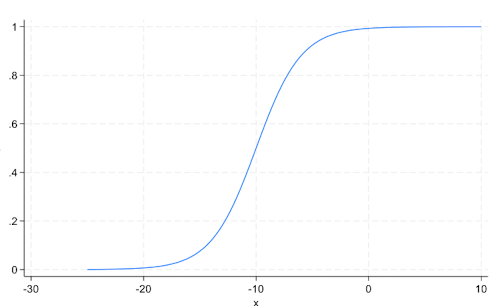

In [4]:
Image("../data/Logistic-regression/sigmoidal.png")

- Classifying a new observation $i$: 
$$\hat{y_i} = \begin{cases}
1 & \text{if } p_i \geq 0.5 \space \text{(Or any threshold)}\\
0 & \text{otherwise}
\end{cases}$$

## Odds
$$\text{odds} = \frac{p}{1-p} = \frac{P(y=1)}{P(y=0)}, \space \text{given} \space p=P(y=1|X)$$
- _E.g.,_ "The odds of winning are 3:2". 
  - In this case, the _odds_ is $\frac{3}{2} = 1.5$.
- **Odds** are specifically about the chance of $y=1$ vs. $y=0$. 

## Intepreting Coefficients
Assume that the two equations below differ by $1$ unit of $x_i$. 
$$\text{log}\frac{p_i}{1-p_i} = \beta_0 + \beta_1(x_1+1) + ... + \beta_p x_p$$
$$\text{log}\frac{p_j}{1-p_j} = \beta_0 + \beta_1x_1 + ... + \beta_p x_p$$
And,

$$\text{log}\frac{p_i}{1-p_i} - \text{log}\frac{p_j}{1-p_j} = \beta_1$$
$$\text{log}\frac{\frac{p_i}{1-p_i}}{\frac{p_j}{1-p_j}}= \beta_1$$
$$\beta_1 = \text{log}\frac{\text{odds}_i}{\text{odds}_j}$$
$$\text{exp}(\beta_1) = \frac{\text{odds}_i}{\text{odds}_j}$$
We can rearrange it as,

$$\text{odds}_j \times \text{exp}(\beta_1) = \text{odds}_i$$

We can state that increasing $x_i$ by $1$, the odds of $y=1$ increase by factor of $\exp(\beta_1)$.

### Example
#### Understanding Coefficients
$$\text{logit}(p_\text{admit}) = -10 + 0.15x_{\text{Average}}$$
Assume that the equation above depicts the probability of being admitted to graudate school as a function of the applicant's undergrad average, where an example value of $x$ would be $75, 80$. 

Here, we can interpret that **each additional percentage point** on the average score increases the **odds of admission** by a factor of $\text{exp}(0.15) = 1.16$.

In logistic regression, estimated coefficients are **normally distributed**. Thus, it follows a $z$-statistic, where $z = \frac{\hat{\beta} - \beta_0}{se}$. If $\hat{\beta}$ is approximately normal, then $z \sim N(0,1)$. 

#### Interpreting Probability
Assume that if $x=80$, our equation would be:
$$\text{logit}(p_\text{admit}) = -10 + 0.15 \times 80 = 7.389$$
And since We know that:

$$p = \frac{1}{1+e^{-z}} \space \text{where} \space z=7.389$$
$$p = \frac{1}{1+e^{-7.389}} = 0.9994$$

We can conclude that when $x=80$, the model predicts that the probability of admission is approximately $99.94$%. 

## Estimation
- **Estimation** means finding the _best values_ of the model parameters ($\beta_i$) using data.

$$
L(\beta) = \prod_{i=1}^N \left[p(x_i;\beta)\right]^{y_i} \cdot \left[1 - p(x_i;\beta)\right]^{1 - y_i}
$$

- Coefficients are _maximized_ by **Maximum Likelihood**, where $p(x; \beta) = \frac{e^{x'\beta}}{1+e'\beta}$, and where $y_i$ is $0$ or $1$, and $x_i$ is a **vector**.

### Properties of MLE
- **Consistency**: As sample size $n$ approaches $\infty$, the estimates converge to the true value. Hence, $\hat{\beta}$ → $\beta$. 
- **Asymptotic normality**: For large $n$, the estimator is approximately normal. Hence, for a parameter, $\hat{\beta} \sim N(\beta, \text{Var})$. 
- **Efficiency**: MLE achieves the lowest possible variance among unbiased estimators.
  - _Unbiased estimator_ refers to an estimator that equals the true parameter value. Hence, $\mathbb{E}[\hat{\theta}] = \theta$.
    - Repeat the experiment many times, and each time you compute $\hat{\theta}$, you take the average of all those estimates. If that average equals the true value, it is **unbiased**. 
- **Invariance**: If $\hat{\theta}$ is the MLE of $0$, then: $g(\hat{\theta})$ is the MLE of $g(\theta)$. 
  - If $\hat{\theta}$ is the MLE of $\theta$, then applying any function called $g()$ results in $g(\theta)$ being the MLE of $g(\theta)$. 

## Usage
- **Logistic regression** is less prone to overfitting.
  - Due to _linearity_ making the fit highly inflexible, and there is no tuning parameter. 
    - Cannot bend or wiggle to fit noise. 
    - Can only capture _simple patterns._
- Excels at explaining how individual variables relate to the outcome. 
- Use for binary outcomes and if we want to capture probabilities. 
- Suggested dataset size is approximately medium. 
- Simple, stable, and well-regularized. Hence performs well on real classification problems. 
- Has **low variance**, so does not overfit easily.
  - Since logistic regression models ($\log(\frac{p}{1-p})$) are linear in features, and the decision boundary cannot adapt too much to random noise. Cannot bend to fit small fluctuations.  
- Produces good probability estimates.

## Limitations
- When the data relationship is highly nonlinear, with complex interactions and nonlinear boundaries. 
  - Instead, explore _gradient boosting_ or _random forest_. 
- When the dat is highly sparse and is high-dimensional. 
- When classes are extremely imbalanced. 
  - Can still use logistic regression, but needs a proper _class weighing_ and _threshold tuning_. 
  - This is because the model is trained to minimize _overall error_, not to treat both classes equally. 
    - When there is a class majorly dominating the other, logistic regression model can predict everything as major class and still achieve higher accuracy. 
    - _Class weighing_ assigns higher penalty to mistakes on minority class. 

---
# LASSO Regression
## Regularization
### Criterion
- **Regularization** refers to a penalty implied on models to manage tradeoff between overfitting and underfitting.
- **Criterion**: MSE + Penalty. 
  - Least squares estimator: $\text{MSE} = \frac{\text{RSS}}{n}$, where **RSS** is the Residual Sum Squares, and is $\text{RSS} = \sum_{i=1}^n(y_i-\beta^tx)^2$.
    - The Least Square Estimator finds the coefficients that **minimize** the sum of squared errors between observed and predicted values. 
  - Hence, $\text{Criterion} = \frac{\text{RSS}}{n} + \text{Penalty}$ for **Least Squares Estimator**. 

### L2 Ridge Regression
- L2 penalty is defined as:
$$\text{Criterion} = \frac{\text{RSS}}{n} + \frac{1}{n}\|\beta \|\text{,}  \space \text{where } \| \beta \| = \sqrt{\sum_{i=1}^p\beta_i^2}$$
- $\| \beta \|$ is the L2 or Euclidean norm of coefficients.
- This penalty favours smaller squared coefficients; strongly penalizes large coefficients.
- No penalty when all coefficients equal zero.
- Dividing by $n$ can be skipped.
- Can be simplified to:
$$\text{Criterion} = \frac{\text{RSS}}{n} + \frac{1}{n}\sum_{j=1}^p{\beta_j^2}$$
  - Square root can be removed as square root is a monotonically increasing function. 
- With regularization parameter $\lambda$ that decides on how large a penalty should be, 
$$\text{Criterion} = \frac{\text{RSS}}{n} + \frac{\lambda}{n}\sum_{j=1}^p{\beta_j^2}\text{ ; }\lambda> 0$$
- Coefficients do not shrink to zero. When variables are highly correlated, L2 regulazation performs better. 

#### Methods for the best $\lambda$
1. Estimate $\lambda$ via cross validation.
2. Find the $\beta$'s in the linear model that minimize the criterion above. 
3. Rely on AIC or BIC.

#### Different Notation
Can also be written as...
$$\min_{\beta}(\text{RSS} + \lambda\sum_{j=1}^p\beta_j^2) \quad \text{such that} \quad \sum_{j=1}^p \beta_j^2 \le s$$
Here, errors are minimized subject to a constraint. 
- $s$: constraint on total coefficient size. 
- For every $\lambda$, there exists some $s$.
- For every $s$, there exists some $\lambda$. 
- If there are two $x$-variables, then $\beta_1^2+\beta_2^2 \leq s$.

### L1 LASSO Regression
- When we don't want to penalize large coefficients as strongly. 
$$\text{Criterion} = \frac{\text{RSS}}{n} + \frac{1}{n}\sum_{j=1}^p{|\beta_j|}\text{ ; }\lambda> 0$$
- Here, coefficients are shrinked to zero. Used for **variable selection**. 
- In general, works better with MSE or accuracy in comparison to L1 regression. Hence, better for predictions as well.
- Large $\lambda$ means selecting fewer variables.

#### Different Notation
$$\min_{\beta}(\text{RSS} + \lambda\sum_{j=1}^p|\beta_j|) \quad \text{such that} \quad \sum_{j=1}^p |\beta_j| \le s$$
- $s$: constraint on total coefficient size. 
- If there are two $x$-variables, then $|\beta_1|+|\beta_2| \leq s$.

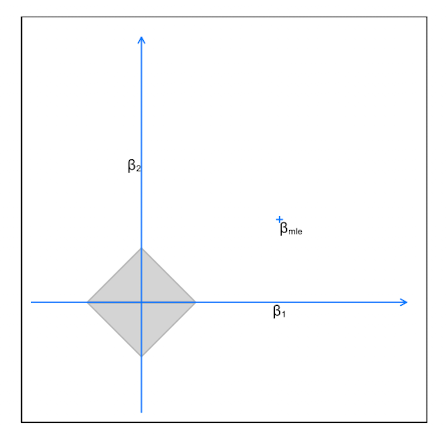

In [8]:
Image("../data/Logistic-regression/L1.png")

- Every corners of the diamond correspond to one of $\beta_1$ and $\beta_2$ being $0$. 

| Property                | L1 (Lasso)                          | L2 (Ridge)                          |
|------------------------|-------------------------------------|-------------------------------------|
| Penalty                | $\sum |\beta_j|$                    | $\sum \beta_j^2$                    |
| Feature selection      | Yes (sets some coefficients to 0)   | No (keeps all features)             |
| Sparsity               | Produces sparse models              | No sparsity                         |
| Correlated features    | Tends to pick one                   | Distributes weights across them     |
| Stability              | Less stable                         | More stable                         |
| Best use case          | High-dimensional, few relevant vars | Many relevant, correlated features  |
| Interpretability       | High                                | Moderate                            |

## Regularized Logistic Regression
- From the **regularization criterion** above, replace $\text{RSS}$ with $\log \text{likelihood}$. 
  - Instead of RSS minimization, likelihood must be maximized. (Or, minimize the negative likelihood.)
$$\text{Criterion} = -\log\text{likelihood} + \frac{1}{n}\sum_{j=1}^p{\beta_j^2}\text{ ; }\lambda> 0$$
$$\text{Criterion} = -\log\text{likelihood} + \frac{1}{n}\sum_{j=1}^p{\beta_j^2}\cdot\text{Var}(x_j)$$
- Sometimes, $\text{Var}(x_j)$ is included by taking into account the different scales of $x$-variables.
  - Because, if left as is, $\beta_j^2$ assigns smaller coefficient to features with large scales. To make this fair across all features, apply *variance-weighted* penalty. 
  - In this case, no need to standardize $x$-variables.

## SVM Regulazation
- **SVM** tries to maximize the margin between classes while allowing some errors ($\epsilon_i$).
- SVM is another regularized optimization problem with a different loss function.
  - **Loss function**: Measure of how wrong the model's predictions are. Smaller the better. 
    - $\text{Loss = error between } y \text{ and } \hat{y}$.
- Find a boundary, $f(x) = \beta_0 + \beta^T x$, that can make correct classifications with a large margin. 
$$\min_{\beta} \sum_{i=1}^n \max(0, 1 - y_i f(x_i)) + \lambda \sum_{j=1}^p \beta_j^2$$
- We are minimizng the loss and penalty added together. 
 - Loss: $\sum_{i=1}^n \max(0, 1 - y_i f(x_i))$. This is **hinge loss**. 
   - $y_i \in \{-1, +1\}$; True label classes are either encoded as $-1$ or $+1$. 
   - In SVM, $+1$ refers to one class, and $-1$ refers to other class. 

| Case                  | Value           |
|-----------------------|-----------------|
| Correct and far away  | 0               |
| Correct but close     | small penalty   |
| Wrong                 | large penalty   | 